## Проект на тему "Для каких типов рядов какая трансформация ряда полезнее?"

In [15]:
import os
import sys
import numpy as np
import pandas as pd
from tqdm import tqdm

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
from config import TSOptimizationConfig
from src.preprocessing import get_experiment_data
from src.clusterization import get_cluster_mapping
from src.baseline_model import get_basilne_metrics
from src.global_model import get_global_metrics
from src.utils import baseline_data_split
from src.transformations import transform_dfs

C:\Users\79160\anaconda3\Lib\site-packages\tslearn\bases\bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


In [3]:
config = TSOptimizationConfig()

### 1. Load data

In [4]:
exp_data, exp_data_wide = get_experiment_data()

### 2. Get clusters

In [5]:
clusters_map = get_cluster_mapping(exp_data_wide)

### 3. Run Experiments

In [ ]:
res_vals = {}
transform_methods = [None, "diff", "boxcox", "log1p"]
exp_data_clust = exp_data.assign(clust=lambda df: df['id'].map(clusters_map)).copy()
for clust, df in tqdm(exp_data_clust.groupby('clust')):
    df_sample = df.drop(columns=["clust"])
    for transform in tqdm(transform_methods):
        train_df, val_df, test_df = baseline_data_split(df_sample, config)
        train_df, val_df, test_df, params = transform_dfs(train_df, val_df, test_df, method=transform)
        baseline_res = get_basilne_metrics(train_df, val_df, test_df, config, params=params)
        res_vals[f"{transform}_clust_{clust}"] = baseline_res.iloc[1:].mean()

In [20]:
res_vals

{'None_clust_0': AutoETS          1.768828
 AutoTheta        1.718696
 Naive            3.616200
 SeasonalNaive    2.200716
 dtype: float64,
 'diff_clust_0': AutoETS           1.486787
 AutoTheta         2.087861
 Naive            13.900208
 SeasonalNaive     1.725516
 dtype: float64,
 'boxcox_clust_0': AutoETS          1.726570
 AutoTheta        1.679747
 Naive            3.712912
 SeasonalNaive    2.199959
 dtype: float64,
 'log1p_clust_0': AutoETS          1.757216
 AutoTheta        1.716703
 Naive            3.616200
 SeasonalNaive    2.200716
 dtype: float64,
 'None_clust_1': AutoETS          1.502136
 AutoTheta        1.629316
 Naive            2.688704
 SeasonalNaive    1.776643
 dtype: float64,
 'diff_clust_1': AutoETS          1.527275
 AutoTheta        2.208090
 Naive            6.440700
 SeasonalNaive    1.588294
 dtype: float64,
 'boxcox_clust_1': AutoETS          1.534080
 AutoTheta        1.586582
 Naive            2.820266
 SeasonalNaive    1.636512
 dtype: float64,
 'lo

In [ ]:
res_vals_global = {}
transform_methods = [None, "diff", "boxcox", "log1p"]
exp_data_clust = exp_data.assign(clust=lambda df: df['id'].map(clusters_map)).copy()
for clust, df in tqdm(exp_data_clust.groupby('clust')):
    df_sample = df.drop(columns=["clust"])
    for transform in tqdm(transform_methods):
        train_df, val_df, test_df = baseline_data_split(df_sample, config)
        train_df, val_df, test_df, params = transform_dfs(train_df, val_df, test_df, method=transform)
        baseline_res = get_global_metrics(train_df, val_df, test_df, config, params=params)
        res_vals_global[f"{transform}_clust_{clust}"] = baseline_res.iloc[1:].mean()

In [23]:
res_vals_global

{'None_clust_0': preds    4.683398
 dtype: float64,
 'diff_clust_0': preds    4.628938
 dtype: float64,
 'boxcox_clust_0': preds    177.82928
 dtype: float64,
 'log1p_clust_0': preds    4.395196
 dtype: float64,
 'None_clust_1': preds    6.504892
 dtype: float64,
 'diff_clust_1': preds    4.01569
 dtype: float64,
 'boxcox_clust_1': preds    149.411681
 dtype: float64,
 'log1p_clust_1': preds    4.916577
 dtype: float64,
 'None_clust_2': preds    5.203088
 dtype: float64,
 'diff_clust_2': preds    4.933519
 dtype: float64,
 'boxcox_clust_2': preds    191.471478
 dtype: float64,
 'log1p_clust_2': preds    5.473566
 dtype: float64}

### 4. Get baseline results

In [5]:
train_df, val_df, test_df = baseline_data_split(exp_data, config)

In [6]:
train_df, val_df, test_df, params = transform_dfs(train_df, val_df, test_df, method="diff")

C:\Users\79160\Downloads\tsa\project\src\transformations.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_g["target"] = train_diff
C:\Users\79160\Downloads\tsa\project\src\transformations.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_g["target"] = val_diff
C:\Users\79160\Downloads\tsa\project\src\transformations.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

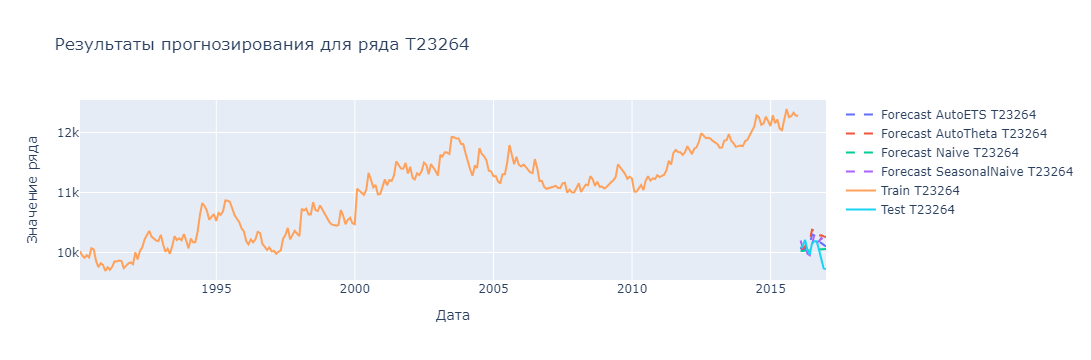

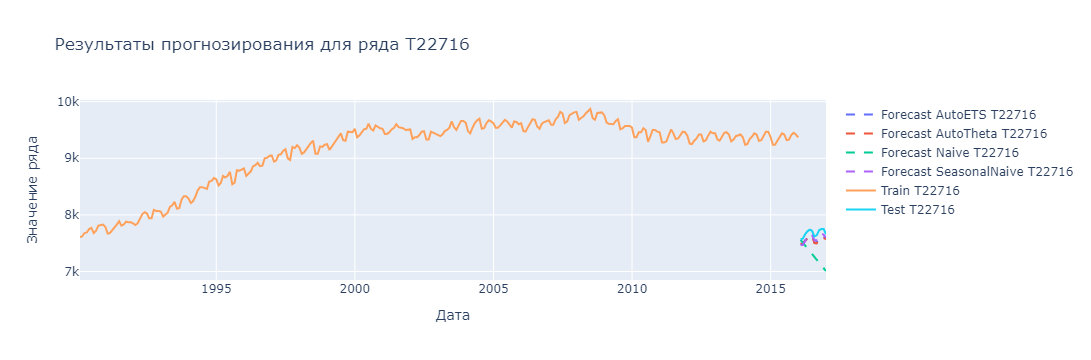

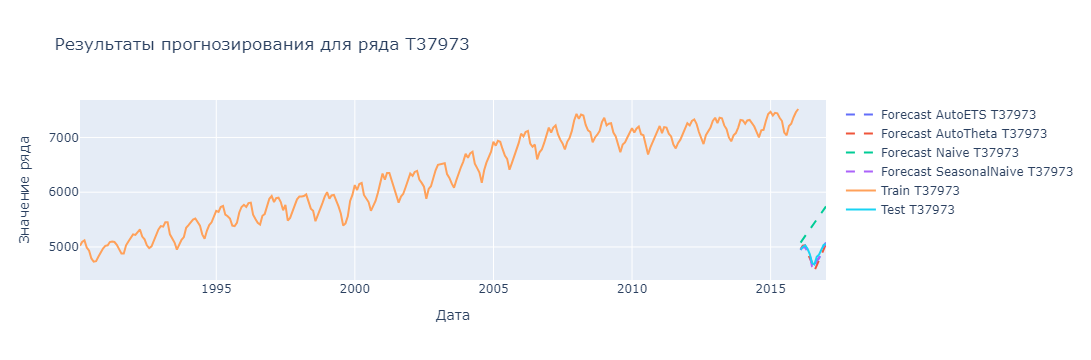

In [7]:
baseline_res = get_basilne_metrics(train_df, val_df, test_df, config, plot=True, params=params)

In [8]:
res = baseline_res.iloc[1:].mean()

### 5. Get global results

0:	learn: 76.7326550	test: 73.7046231	best: 73.7046231 (0)	total: 172ms	remaining: 17s
99:	learn: 46.0286609	test: 41.6921736	best: 41.6921736 (99)	total: 2.29s	remaining: 0us

bestTest = 41.69217355
bestIteration = 99

Шаг прогнозирования 1 из 12
Шаг прогнозирования 2 из 12
Шаг прогнозирования 3 из 12
Шаг прогнозирования 4 из 12
Шаг прогнозирования 5 из 12
Шаг прогнозирования 6 из 12
Шаг прогнозирования 7 из 12
Шаг прогнозирования 8 из 12
Шаг прогнозирования 9 из 12
Шаг прогнозирования 10 из 12
Шаг прогнозирования 11 из 12
Шаг прогнозирования 12 из 12


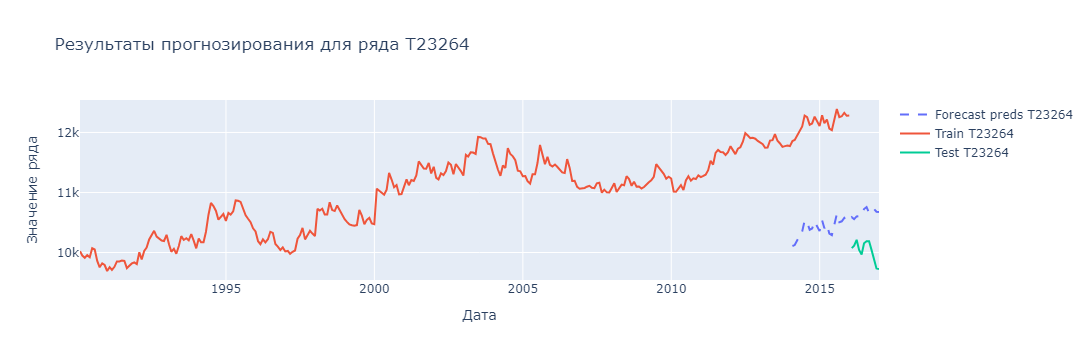

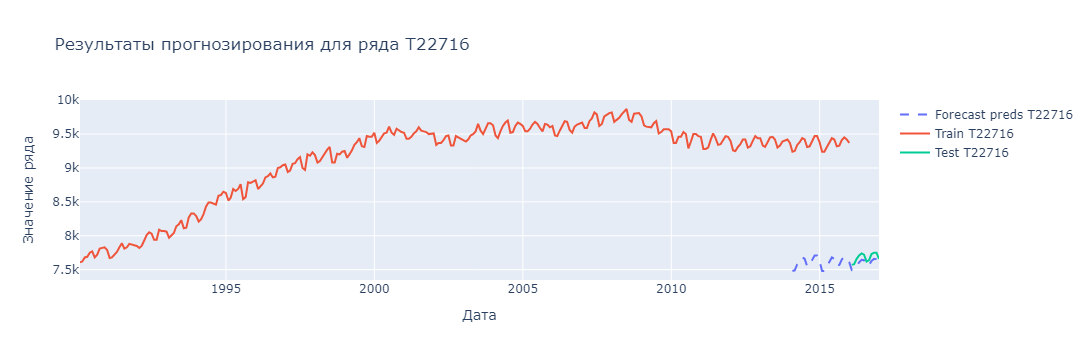

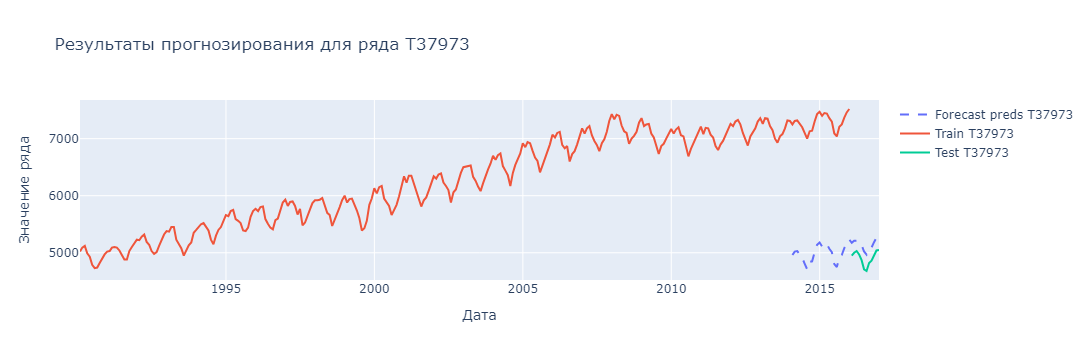

In [9]:
global_res = get_global_metrics(train_df, val_df, test_df, config, plot=True, params=params)